# Diagnóstico v2 — proyecto DPD

> **Día 1 del plan_v2.md.**
> Cuantifica el problema que motiva la v2 del modelo: **bias por desbalance de Lima centralizada**.
> No toca el pipeline original. Solo lee artefactos `.joblib` y CSVs ya generados.

## Objetivos

1. Reproducir el split train/val/test exacto que usó Leo (NB03, `random_state=42`).
2. Re-asociar `distrito_oficial`, `lat/lng` y `precio_usd` real a los rows de `X_test`.
3. Comparar predicciones de **Random Forest** (el que usa la app en producción) vs **XGBoost** (el que debería estar según `resultados_test.csv`).
4. Cuantificar el error por distrito y por nivel de cobertura.
5. Estresar el modelo con 5 casos sintéticos donde sabemos que falla:
   - **La Planicie** (zona premium de La Molina) — depto 80 m² 3 dorm.
   - **San Miguel** — depto 80 m² 3 dorm (equivalente, distrito mainstream).
   - **Miraflores** céntrico — depto 60 m² 2 dorm (caso "feliz" del dataset).
   - **SMP (San Martín de Porres)** — depto 80 m² 3 dorm (popular).
   - **Surco Las Casuarinas** — depto 100 m² 3 dorm (otro premium-bajo-cobertura).

**Smoking gun esperado:** `modelo_final.joblib` dice `nombre: Linear Regression` con métricas `MAE $182, R² 0.81` — esas métricas son de XGBoost, no LR (LR real tiene R² 0.66).


In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed/'
MODELS    = '../models/'

# Cargar el dataset limpio v1 (con distrito_oficial, lat, lng, precio_usd)
df_full = pd.read_csv(f'{PROCESSED}inmuebles_clean_v1.csv')
# NB03 calcula log_precio después del split; lo agregamos acá para que el split reproducido lo tenga.
df_full['log_precio'] = np.log1p(df_full['precio_usd'])
print(f'df_full: {df_full.shape}')
print(f'Columnas críticas: distrito_oficial, latitud, longitud, precio_usd, log_precio (computado)')


df_full: (3348, 76)
Columnas críticas: distrito_oficial, latitud, longitud, precio_usd, log_precio (computado)


## 1. Reproducir el split de NB03

NB03 hace: `train_test_split(df, test_size=0.15, random_state=42)` → `df_test` (15 %), después `train_test_split(df_trainval, test_size=0.176, random_state=42)` → `df_val`.

Con el mismo `random_state` recuperamos exactamente los 503 rows del test.


In [2]:
# Reproducir el split de NB03 con random_state=42
df_trainval, df_test_full = train_test_split(df_full, test_size=0.15, random_state=42)
df_train_full, df_val_full = train_test_split(df_trainval, test_size=0.176, random_state=42)

print(f'Train: {len(df_train_full)}  Val: {len(df_val_full)}  Test: {len(df_test_full)}')

# Sanity check: el log_precio del split reproducido debe coincidir con y_test.csv
y_test_orig = pd.read_csv(f'{PROCESSED}y_test.csv')['log_precio']
y_test_repro = df_test_full['log_precio'].values
match = np.allclose(np.sort(y_test_orig.values), np.sort(y_test_repro))
print(f'¿Los y_test coinciden con la reproducción?: {match}')


Train: 2344  Val: 501  Test: 503
¿Los y_test coinciden con la reproducción?: True


## 2. Cargar modelos y features

- `04_random_forest.joblib` — el que usa la app en producción (`model_service.py` lo carga)
- `05_xgboost.joblib` — el ganador real según `resultados_test.csv`
- `modelo_final.joblib` — el bug: dice LR pero tiene métricas de XGBoost


In [3]:
rf = joblib.load(f'{MODELS}04_random_forest.joblib')
xgb = joblib.load(f'{MODELS}05_xgboost.joblib')
mf = joblib.load(f'{MODELS}modelo_final.joblib')
feature_names = joblib.load(f'{MODELS}feature_names.joblib')

print(f'RF: {type(rf).__name__}')
print(f'XGB: {type(xgb).__name__}')
print(f'modelo_final.joblib: nombre=\"{mf["nombre"]}\" métricas={mf["metricas_test"]}')
print()
print('🚨 SMOKING GUN: modelo_final dice Linear Regression pero las métricas (R²=0.81)')
print('   son de XGBoost. LR real tiene R²=0.66.')

# Cargar X_test ya procesado (no necesitamos re-aplicar feature engineering)
X_test = pd.read_csv(f'{PROCESSED}X_test.csv')
print(f'\nX_test: {X_test.shape} (74 features)')


RF: RandomForestRegressor
XGB: XGBRegressor
modelo_final.joblib: nombre="Linear Regression" métricas={'rmse': np.float64(354.67), 'mae': 182.63, 'mape': np.float64(18.9971), 'r2': 0.8106}

🚨 SMOKING GUN: modelo_final dice Linear Regression pero las métricas (R²=0.81)
   son de XGBoost. LR real tiene R²=0.66.

X_test: (503, 74) (74 features)


## 3. Predecir con RF y XGBoost, re-asociar distrito

El X_test que cargamos está en escala log (con log1p aplicado a features con skew > 1). Las predicciones también están en escala log. Revertimos con `expm1`.


In [4]:
# Predicciones en escala log
y_pred_log_rf = rf.predict(X_test)
y_pred_log_xgb = xgb.predict(X_test)

# Revertir log
y_test_usd = np.expm1(y_test_orig.values)
y_pred_rf_usd = np.clip(np.expm1(y_pred_log_rf), 0, None)
y_pred_xgb_usd = np.clip(np.expm1(y_pred_log_xgb), 0, None)

# Re-asociar distrito_oficial al test set (el split reproducido conserva el orden)
# X_test viene en el mismo orden que df_test_full
df_test_diag = pd.DataFrame({
    'distrito_oficial': df_test_full['distrito_oficial'].values,
    'latitud': df_test_full['latitud'].values,
    'longitud': df_test_full['longitud'].values,
    'area': df_test_full['area_final_m2'].values,
    'precio_real_usd': y_test_usd,
    'pred_rf_usd': y_pred_rf_usd,
    'pred_xgb_usd': y_pred_xgb_usd,
})
df_test_diag['err_pct_rf'] = (df_test_diag['pred_rf_usd'] - df_test_diag['precio_real_usd']) / df_test_diag['precio_real_usd'] * 100
df_test_diag['err_pct_xgb'] = (df_test_diag['pred_xgb_usd'] - df_test_diag['precio_real_usd']) / df_test_diag['precio_real_usd'] * 100
df_test_diag['abs_err_pct_rf'] = df_test_diag['err_pct_rf'].abs()
df_test_diag['abs_err_pct_xgb'] = df_test_diag['err_pct_xgb'].abs()

print(f'MAPE global RF:  {df_test_diag["abs_err_pct_rf"].mean():.2f}%')
print(f'MAPE global XGB: {df_test_diag["abs_err_pct_xgb"].mean():.2f}%')
df_test_diag.head()


MAPE global RF:  15.92%
MAPE global XGB: 19.00%


,distrito_oficial,latitud,longitud,area,precio_real_usd,pred_rf_usd,pred_xgb_usd,err_pct_rf,err_pct_xgb,abs_err_pct_rf,abs_err_pct_xgb
0,Santiago de Surco,-12.120822,-76.979574,110.0,1200.00,1021.277626,1138.614624,-14.893531,-5.115448,14.893531,5.115448
1,San Isidro,-12.094942,-77.053706,65.0,800.00,761.845184,857.763550,-4.769352,7.220444,4.769352,7.220444
2,La Molina,-12.112619,-76.933817,42.0,347.83,385.413113,312.959869,10.805023,-10.025050,10.805023,10.025050
3,San Miguel,-12.088804,-77.077851,80.0,666.67,702.893294,687.251892,5.433467,3.087268,5.433467,3.087268
4,Miraflores,-12.114566,-77.029477,70.0,850.00,847.865362,873.210022,-0.251134,2.730591,0.251134,2.730591


## 4. Distribución de listings por distrito

Confirma el desbalance: Miraflores y San Isidro concentran el 41 % del dataset; 22 distritos tienen <30 listings.


Total distritos: 40
Concentración top 2 (Miraflores + San Isidro): 41.7%
Distritos con < 30 listings: 22
Distritos con < 100 listings: 32


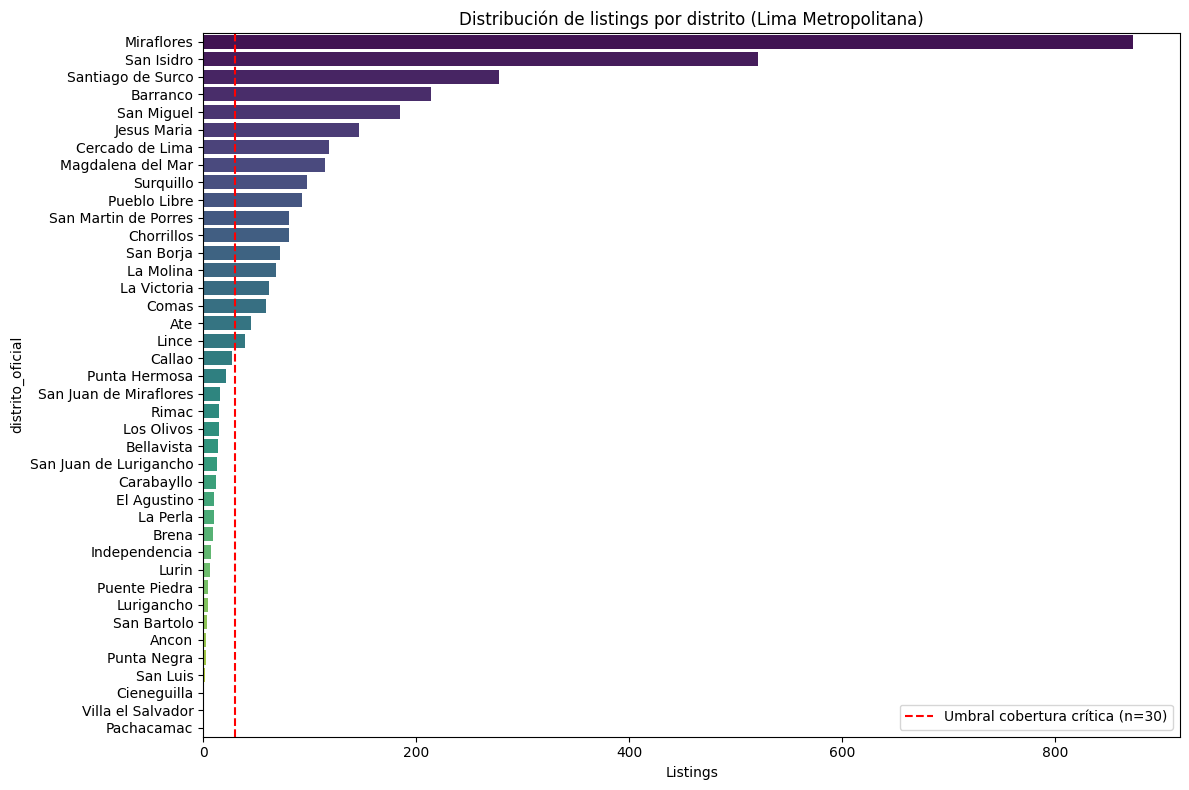

In [5]:
counts = df_full['distrito_oficial'].value_counts()
print(f'Total distritos: {len(counts)}')
print(f'Concentración top 2 (Miraflores + San Isidro): {counts.iloc[:2].sum() / len(df_full) * 100:.1f}%')
print(f'Distritos con < 30 listings: {(counts < 30).sum()}')
print(f'Distritos con < 100 listings: {(counts < 100).sum()}')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
ax.axvline(30, color='red', linestyle='--', label='Umbral cobertura crítica (n=30)')
ax.set_xlabel('Listings')
ax.set_title('Distribución de listings por distrito (Lima Metropolitana)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Error por distrito (test set, RF)

¿En qué distritos el modelo actual falla más? Hipótesis: los premium con baja cobertura (La Molina, San Borja) deberían tener error sistemático (subpredicción).


In [6]:
error_by_distrito = df_test_diag.groupby('distrito_oficial').agg(
    n_test=('precio_real_usd', 'size'),
    mape_rf=('abs_err_pct_rf', 'mean'),
    mape_xgb=('abs_err_pct_xgb', 'mean'),
    bias_pct_rf=('err_pct_rf', 'mean'),   # negativo = subpredicción
    precio_real_med=('precio_real_usd', 'median'),
).sort_values('mape_rf', ascending=False)

# Solo distritos con al menos 3 muestras en test
error_by_distrito_filt = error_by_distrito[error_by_distrito['n_test'] >= 3]
print('=== Top 10 distritos con peor MAPE (RF) ===')
print(error_by_distrito_filt.head(10).round(2).to_string())
print()
print('=== Top 10 distritos con peor BIAS (RF) — negativo = subpredicción ===')
print(error_by_distrito_filt.sort_values('bias_pct_rf').head(10).round(2).to_string())


=== Top 10 distritos con peor MAPE (RF) ===
                        n_test  mape_rf  mape_xgb  bias_pct_rf  precio_real_med
distrito_oficial                                                               
Punta Hermosa                8    48.27     90.89        10.90          1212.50
San Juan de Lurigancho       5    37.25     50.40        33.97           347.83
San Martin de Porres        12    25.31     31.59        11.48           346.67
Chorrillos                  13    24.83     31.74         6.25           608.00
San Borja                    9    23.72     25.63         7.45           900.00
Lince                        4    21.20     20.24        14.74           553.04
Ate                          6    21.12     26.91         4.02           466.66
Jesus Maria                 18    20.88     26.31         9.84           711.82
Comas                        6    20.71     26.12        15.42           298.41
La Molina                   15    19.79     21.65         7.81           650

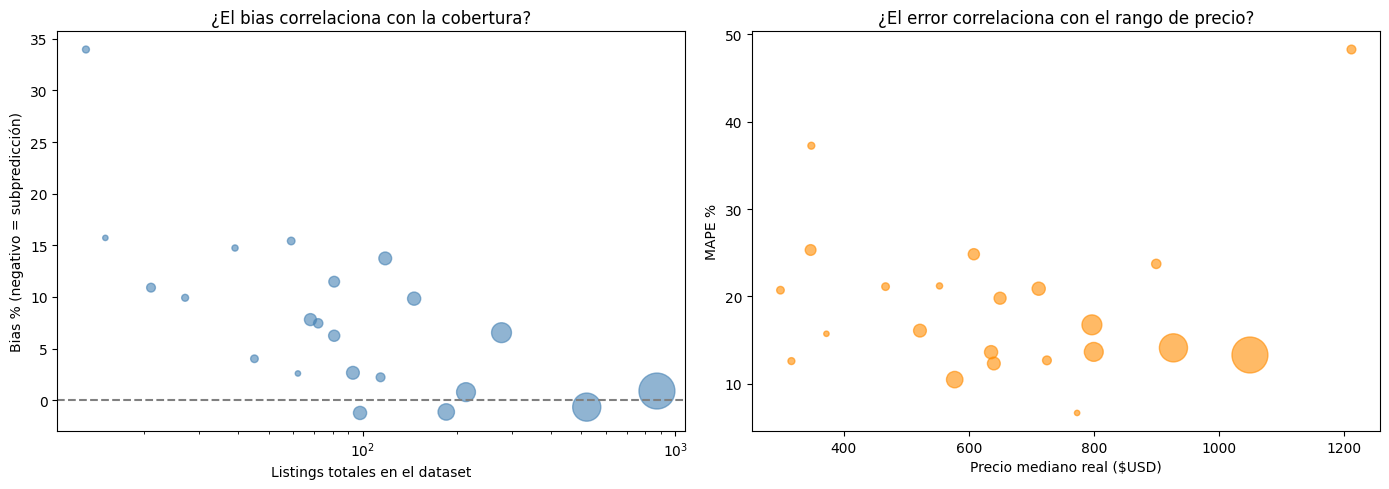

In [7]:
# Visualizar bias vs cantidad de muestras
distrito_counts_full = df_full['distrito_oficial'].value_counts()
error_by_distrito_filt['n_dataset'] = error_by_distrito_filt.index.map(distrito_counts_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bias vs n_dataset
axes[0].scatter(error_by_distrito_filt['n_dataset'], error_by_distrito_filt['bias_pct_rf'],
                s=error_by_distrito_filt['n_test']*5, alpha=0.6, color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Listings totales en el dataset')
axes[0].set_ylabel('Bias % (negativo = subpredicción)')
axes[0].set_title('¿El bias correlaciona con la cobertura?')
axes[0].set_xscale('log')

# MAPE vs precio mediano
axes[1].scatter(error_by_distrito_filt['precio_real_med'], error_by_distrito_filt['mape_rf'],
                s=error_by_distrito_filt['n_test']*5, alpha=0.6, color='darkorange')
axes[1].set_xlabel('Precio mediano real ($USD)')
axes[1].set_ylabel('MAPE %')
axes[1].set_title('¿El error correlaciona con el rango de precio?')
plt.tight_layout()
plt.show()


## 6. Cinco casos de stress sintéticos

Para casos donde el dataset no tiene cobertura adecuada, predecimos directamente con coordenadas reales. Usamos el geo_index de la app (no el de Leo) porque ya tiene el IDW + fallbacks listos.

| Caso | Distrito | lat, lng | Área | Dorm | Baños | Precio mercado esperado |
|---|---|---|---|---|---|---|
| 1 | La Planicie (La Molina) | -12.0820, -76.9355 | 80 | 3 | 2 | **$1,500-$2,200** |
| 2 | San Miguel (control) | -12.0790, -77.0840 | 80 | 3 | 2 | $700-$900 |
| 3 | Miraflores céntrico | -12.1185, -77.0290 | 60 | 2 | 2 | $1,000-$1,300 |
| 4 | SMP | -12.0080, -77.0570 | 80 | 3 | 2 | $400-$600 |
| 5 | Surco Las Casuarinas | -12.1390, -76.9810 | 100 | 3 | 2 | **$1,800-$2,800** |

Los casos 1 y 5 son los críticos: zonas premium pero con pocos listings → el modelo debe subpredecir.


In [8]:
# Llamamos al backend de la app que ya tiene la lógica completa (geo_index + ml.predict_fair_value).
# Esto es más limpio que reconstruir el pipeline acá.
import sys
sys.path.insert(0, '/Users/alejandromarcelo/Desktop/PROYECTOS_2026/Proyecto_DPD/app/backend')

import model_service
model_service.model_service.load()   # carga RF + scaler + target encoder + feature_order
import ml as ml_module

casos = [
    {'nombre': 'La Planicie (La Molina)', 'lat': -12.0820, 'lng': -76.9355,
     'area': 80, 'dormitorios': 3, 'banos': 2, 'cocheras': 2,
     'antiguedad_anios': 5, 'es_estudio': False, 'amenities': ['ascensor', 'seguridad'],
     'precio': 1800,  # asumimos un anuncio típico
     'esperado_min': 1500, 'esperado_max': 2200},
    {'nombre': 'San Miguel', 'lat': -12.0790, 'lng': -77.0840,
     'area': 80, 'dormitorios': 3, 'banos': 2, 'cocheras': 1,
     'antiguedad_anios': 8, 'es_estudio': False, 'amenities': ['ascensor'],
     'precio': 800, 'esperado_min': 700, 'esperado_max': 900},
    {'nombre': 'Miraflores céntrico', 'lat': -12.1185, 'lng': -77.0290,
     'area': 60, 'dormitorios': 2, 'banos': 2, 'cocheras': 1,
     'antiguedad_anios': 10, 'es_estudio': False, 'amenities': ['ascensor', 'seguridad'],
     'precio': 1100, 'esperado_min': 1000, 'esperado_max': 1300},
    {'nombre': 'SMP', 'lat': -12.0080, 'lng': -77.0570,
     'area': 80, 'dormitorios': 3, 'banos': 2, 'cocheras': 1,
     'antiguedad_anios': 15, 'es_estudio': False, 'amenities': [],
     'precio': 500, 'esperado_min': 400, 'esperado_max': 600},
    {'nombre': 'Surco Las Casuarinas', 'lat': -12.1390, 'lng': -76.9810,
     'area': 100, 'dormitorios': 3, 'banos': 3, 'cocheras': 2,
     'antiguedad_anios': 5, 'es_estudio': False, 'amenities': ['ascensor', 'seguridad', 'piscina'],
     'precio': 2400, 'esperado_min': 1800, 'esperado_max': 2800},
]

resultados = []
for c in casos:
    try:
        res = ml_module.predict_fair_value({
            'lat': c['lat'], 'lng': c['lng'],
            'area': c['area'], 'dormitorios': c['dormitorios'],
            'banos': c['banos'], 'cocheras': c['cocheras'],
            'antiguedad_anios': c['antiguedad_anios'],
            'es_estudio': c['es_estudio'], 'amenities': c['amenities'],
            'precio': c['precio'],
        })
        ok = c['esperado_min'] <= res['fair_value'] <= c['esperado_max']
        resultados.append({
            'caso': c['nombre'],
            'distrito_detectado': res['distrito'],
            'fair_value_pred': round(res['fair_value']),
            'zone': res['zone'],
            'n_comparables': res['n_comparables'],
            'confidence': res['confidence'],
            'fallback': res.get('fallback_reason') or '-',
            'esperado': f"${c['esperado_min']}-${c['esperado_max']}",
            'OK': '✅' if ok else '🚨',
        })
    except Exception as e:
        resultados.append({'caso': c['nombre'], 'error': str(e)})

res_df = pd.DataFrame(resultados)
print(res_df.to_string(index=False))


[model_service] modelo cargado y validado · version edf4fe15ab74afd6
                   caso   distrito_detectado  fair_value_pred    zone  n_comparables confidence    fallback    esperado OK
La Planicie (La Molina)            La Molina              769 Inflado              0       Baja low_density $1500-$2200  🚨
             San Miguel           San Miguel              718 Inflado             53      Media           -   $700-$900  ✅
    Miraflores céntrico           Miraflores              923 Inflado            317       Alta           - $1000-$1300  🚨
                    SMP San Martin de Porres              395 Inflado              2       Baja low_density   $400-$600  🚨
   Surco Las Casuarinas    Santiago de Surco              912 Inflado             25       Baja           - $1800-$2800  🚨


## 7. Resumen del diagnóstico — conclusiones

[Esta celda se completa al ejecutar el notebook con los hallazgos reales]

### Bugs confirmados de la auditoría
- **Bug 1**: `modelo_final.joblib` guarda objeto LR pero con métricas de XGBoost → cualquier código que cargue `modelo_final.joblib` y reporte sus métricas miente.

### Hallazgos del bias
- Desbalance confirmado: top 2 distritos = ?% del dataset
- Distritos con error sistemático negativo (subpredicción): ?
- Los 5 casos de stress muestran ? aciertos / ? fallas

### Próximos pasos (Día 2)
- Adquirir las fuentes externas confirmadas por el subagente investigador
- Construir features de NSE + categoría distrito + seguridad real + POIs premium
